In [11]:
import tiktoken

encoding = tiktoken.encoding_for_model("gpt-4o")
print(encoding.name)

system_message = """
Perform sentiment analysis of the review presented in the user message.
The result should be positive or negative. Do not justify your response.
"""

tokens = encoding.encode(system_message)

print(len(tokens))
print(tokens)

for token in tokens:
    print(encoding.decode_single_token_bytes(token), end="")

def num_tokens_from_string(string: str, encoding_name: str = "o200k_base") -> int:
    """Returns the number of tokens in a text string."""
    encoding = tiktoken.get_encoding(encoding_name)
    num_tokens = len(encoding.encode(string))
    return num_tokens

print()
print(num_tokens_from_string("tiktoken is great!"))

o200k_base
27
[198, 73751, 39160, 8450, 328, 290, 3358, 13392, 306, 290, 1825, 3176, 558, 976, 1534, 1757, 413, 8841, 503, 12626, 13, 3756, 625, 14883, 634, 3322, 558]
b'\n'b'Perform'b' sentiment'b' analysis'b' of'b' the'b' review'b' presented'b' in'b' the'b' user'b' message'b'.\n'b'The'b' result'b' should'b' be'b' positive'b' or'b' negative'b'.'b' Do'b' not'b' justify'b' your'b' response'b'.\n'
6


In [12]:
from langchain_ollama import ChatOllama

llm = ChatOllama(model="llama3.2")

response = llm.invoke([
    {
        "role": "system",
        "content": "You are a helpful assistant. The output should be in Markdown"
    },
    {
        "role": "user",
        "content": "C'est quoi un Agent AI"
    }
])

from IPython.display import display, Markdown

display(Markdown(response.content))

**Qu'est-ce qu'un Agent AI ?**

Un agent artificial intelligent (AI) est un programme informatique conçu pour automatiser des tâches spécifiques et prendre des décisions de manière autonome. Les agents AI sont souvent utilisés dans les systèmes intelligents, les systèmes de réseaux sociaux et les applications de traitement d'images.

**Caractéristiques clés des agents AI :**

1. **Objectifs définis** : L'agent AI a un objectif ou une mission spécifique à atteindre.
2. **Résolution de problèmes** : L'agent AI utilise des algorithmes pour résoudre des problèmes et prendre des décisions.
3. **Apprentissage** : L'agent AI peut apprendre de l'expérience et s'améliorer sur le temps.
4. **Interaction avec l'environnement** : L'agent AI interactue avec son environnement pour collecter des informations et prendre des actions.

**Types d'agents AI :**

1. **Agent récurrent** (RNN) : Utilise un modèle de neurones connectés pour traiter les séquences de données.
2. **Agent à graphique** (Graph-based) : Travaille avec des graphiques pour résoudre des problèmes complexes.
3. **Agent à évaluation** (Evaluation-based) : Se concentre sur l'évaluation et la révision des performances.

**Avantages des agents AI :**

1. **Amélioration continue** : Les agents AI peuvent s'améliorer automatiquement sur le temps.
2. **Faites-leur mieux** : Les agents AI peuvent prendre des décisions plus rapides et plus précises que les humains.
3. **Flexibilité** : Les agents AI peuvent être adaptés à différents scénarios et tâches.

**Exemples d'applications des agents AI :**

1. **Vehicules autonomes**
2. **Assistants virtuels**
3. **Systèmes de recommandation**
4. **Joueurs de Jeu vidéo**

En résumé, les agents AI sont des programmes informatiques conçus pour automatiser des tâches spécifiques et prendre des décisions de manière autonome. Ils utilisent des algorithmes pour résoudre des problèmes et interagir avec leur environnement. Les agents AI offrent plusieurs avantages, notamment l'amélioration continue, la précision et la flexibilité.

In [6]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from IPython.display import display, Markdown

# Charger les variables d'environnement (.env)
load_dotenv(override=True)

# Initialiser le modèle
model = ChatOpenAI(
    model="gpt-5.2",  # gpt-5.2 n'existe pas
    temperature=0
)

# Envoyer une requête
response = model.invoke([
    {
        "role": "system",
        "content": "You are a helpful assistant. The output should be in Markdown"
    },
    {
        "role": "user",
        "content": "C'est quoi un Agent AI ?"
    }
])

# Affichage
display(Markdown(response.content))

Un **Agent AI** (ou **agent d’intelligence artificielle**) est un programme capable de **percevoir un contexte**, **prendre des décisions** et **agir** pour atteindre un objectif, souvent de façon **semi-autonome**.

### Ce qui le distingue d’un simple chatbot
Un chatbot répond surtout à des questions. Un **agent**, lui, peut aussi :
- **planifier** une suite d’étapes (ex. “d’abord chercher, puis comparer, puis rédiger”),
- **utiliser des outils** (naviguer sur le web, appeler une API, interroger une base de données, exécuter du code, créer un ticket, envoyer un email, etc.),
- **itérer** (vérifier ses résultats, corriger, recommencer),
- parfois **garder une mémoire** (préférences, contexte, historique) selon le système.

### Comment ça marche (schéma simple)
1. **Objectif** : “Organise mon voyage à Lyon”
2. **Perception** : contraintes, budget, dates, préférences
3. **Raisonnement / plan** : étapes à suivre
4. **Actions** : recherche d’hôtels, comparaison, proposition d’itinéraire
5. **Feedback** : ajuste selon tes retours

### Exemples concrets d’agents AI
- **Assistant de support client** qui classe les demandes, propose une réponse et crée des tickets.
- **Agent de veille** qui surveille des sources, résume et alerte.
- **Agent “ops”** qui diagnostique une panne à partir de logs et propose un correctif.
- **Agent commercial** qui enrichit des leads, rédige des emails personnalisés et met à jour un CRM.

### À savoir
Un agent peut être très utile, mais il faut souvent :
- des **garde-fous** (permissions, validations humaines),
- une gestion des **erreurs** (il peut se tromper),
- des limites d’accès aux outils/données (sécurité).

Si tu me dis ton usage (travail, perso, entreprise) et ce que tu veux automatiser, je peux te proposer un exemple d’agent adapté.

In [ ]:
from langchain_groq import ChatGroq
from IPython.display import display, Markdown
load_dotenv(override=True)
llm2=ChatGroq(model="openai/gpt-oss-120b")

from langchain.messages import SystemMessage, HumanMessage
resp2 = llm2.invoke([SystemMessage("You are a helpful assistant. The output should be in Mark-down"),
HumanMessage("C'est quoi un Agent AI")
])

resp3=llm2.invoke([
    {
        "role": "system",
        "content": "You are a helpful assistant. The output should be in Markdown"
    },
    {
        "role": "user",
        "content": "C'est quoi un Agent AI ?"
    }
])
print(display(Markdown(resp3.content)))

## Qu’est‑ce qu’un **Agent IA** ?  

Un **agent d’intelligence artificielle (IA)** est une entité logicielle capable d’observer son environnement, d’analyser les informations qu’elle reçoit, de prendre des décisions et d’agir en conséquence, généralement de façon autonome ou semi‑autonome.  

### 1. Définition formelle  
Dans la littérature en IA, on définit souvent un agent comme le **triplet** suivant :

\[
\text{Agent} = \langle \text{Perception},\; \text{Modèle (ou Mémoire)},\; \text{Action} \rangle
\]

- **Perception** : capteurs (API, caméras, microphones, bases de données…) qui collectent les données du monde extérieur.  
- **Modèle / Mémoire** : représentation interne (règles, réseaux de neurones, arbres de décision, etc.) qui stocke les connaissances et les expériences passées.  
- **Action** : effecteurs (réponses textuelles, mouvements de robot, appels à d’autres services…) qui modifient l’environnement ou renvoient une sortie à l’utilisateur.

### 2. Types d’agents IA

| Catégorie | Caractéristiques | Exemples concrets |
|-----------|-------------------|-------------------|
| **Agent réactif** | N’a pas de mémoire à long terme ; réagit uniquement aux stimuli courants via des règles simples. | Systèmes de contrôle d’un thermostat, bots de jeu vidéo qui réagissent aux mouvements du joueur. |
| **Agent basé sur le modèle** | Construit un modèle interne de l’environnement (physique, logique). | Simulateurs de conduite autonome qui prévoient la trajectoire des véhicules. |
| **Agent à objectif** | Possède une fonction d’objectif (reward) qu’il cherche à maximiser. | Agents de reinforcement learning (ex. AlphaGo, agents de trading algorithmique). |
| **Agent d’apprentissage** | Met à jour son modèle à partir de nouvelles données (online learning, transfer learning). | Chatbots qui s’ajustent aux préférences de l’utilisateur, assistants vocaux qui s’améliorent avec l’usage. |
| **Agent hybride** | Combine plusieurs des capacités ci‑dessus (réaction rapide + planification + apprentissage). | Robots domestiques (ex. Roomba) qui évitent les obstacles (réactif), planifient le nettoyage (modèle) et apprennent la disposition de la maison (apprentissage). |

### 3. Architecture typique d’un agent IA

```
┌─────────────────────┐
│  Capteurs / Input   │   ← Perception
└─────────┬───────────┘
          │
   ┌──────▼───────┐
   │  Pré‑traitement │
   └──────┬───────┘
          │
   ┌──────▼───────┐
   │   Modèle IA   │   ← Réseaux de neurones, logique floue, arbres de décision…
   └──────┬───────┘
          │
   ┌──────▼───────┐
   │   Décision /  │   ← Politique d’action, fonction de récompense
   │   Planification│
   └──────┬───────┘
          │
   ┌──────▼───────┐
   │  Effecteurs / │   ← Action (texte, commande, mouvement)
   │   Output      │
   └───────────────┘
```

### 4. Différence entre **Agent IA** et **Modèle IA**

| Aspect | Modèle IA | Agent IA |
|--------|-----------|----------|
| **But** | Produire une sortie à partir d’une entrée (ex. classification d’image). | Interagir de façon continue avec un environnement, décider quand et comment agir. |
| **Temporalité** | Souvent statique (une prédiction à la fois). | Dynamique, boucle perception‑action continue. |
| **Mémoire** | Peut être « sans état » (ex. fonction pure). | Possède généralement une forme de mémoire ou d’état interne. |
| **Autonomie** | Aucun contrôle sur le contexte. | Décide lui‑même quand solliciter le modèle, quand explorer, etc. |

### 5. Exemples populaires d’agents IA

| Domaine | Agent | Fonction principale |
|---------|-------|----------------------|
| **Assistants vocaux** | Alexa, Google Assistant, Siri | Compréhension du langage naturel → actions (lecture musique, contrôle domotique). |
| **Jeux** | AlphaGo, OpenAI Five | Décision de coups optimaux via reinforcement learning. |
| **Robots** | Boston Dynamics Spot | Navigation autonome, évitement d’obstacles, exécution de missions. |
| **Chatbots** | ChatGPT (utilisé comme agent) | Génération de réponses, suivi de conversation, adaptation au contexte. |
| **Systèmes de recommandation** | Netflix, Spotify agents | Analyse du comportement utilisateur → suggestions personnalisées. |

### 6. Principaux défis à relever

1. **Sécurité & Fiabilité** – éviter les actions dangereuses ou non désirées.  
2. **Interprétabilité** – comprendre pourquoi l’agent a choisi telle action.  
3. **Alignement des objectifs** – s’assurer que la fonction de récompense reflète les valeurs humaines.  
4. **Gestion de l’incertitude** – opérer dans des environnements partiellement observables ou bruyants.  
5. **Scalabilité** – maintenir la performance quand le nombre de capteurs/acteurs augmente.

### 7. Ressources pour aller plus loin

- **Livres**  
  - *Artificial Intelligence: A Modern Approach* (Russell & Norvig) – chapitres sur les agents.  
  - *Reinforcement Learning: An Introduction* (Sutton & Barto) – agents à objectif.  

- **Cours en ligne**  
  - Coursera – *AI for Everyone* (Andrew Ng) – introduction aux agents.  
  - Udacity – *Deep Reinforcement Learning* – implémentation d’agents autonomes.  

- **Frameworks**  
  - **OpenAI Gym** / **Gymnasium** – environnements pour tester des agents RL.  
  - **ROS (Robot Operating System)** – infrastructure pour les agents robotisés.  
  - **LangChain** – construction d’agents conversationnels qui orchestrent plusieurs modèles et outils.

---

### 🎯 En résumé
Un **agent IA** est bien plus qu’un simple modèle de prédiction : c’est un système qui **perçoit**, **réfléchit** (en s’appuyant sur un modèle ou une mémoire) et **agit** dans un environnement, souvent de façon autonome. Selon le degré de complexité (réactif, planificateur, apprenant), il peut être utilisé dans des domaines très variés, du chatbot à la conduite autonome, en passant par les jeux et la robotique.

None


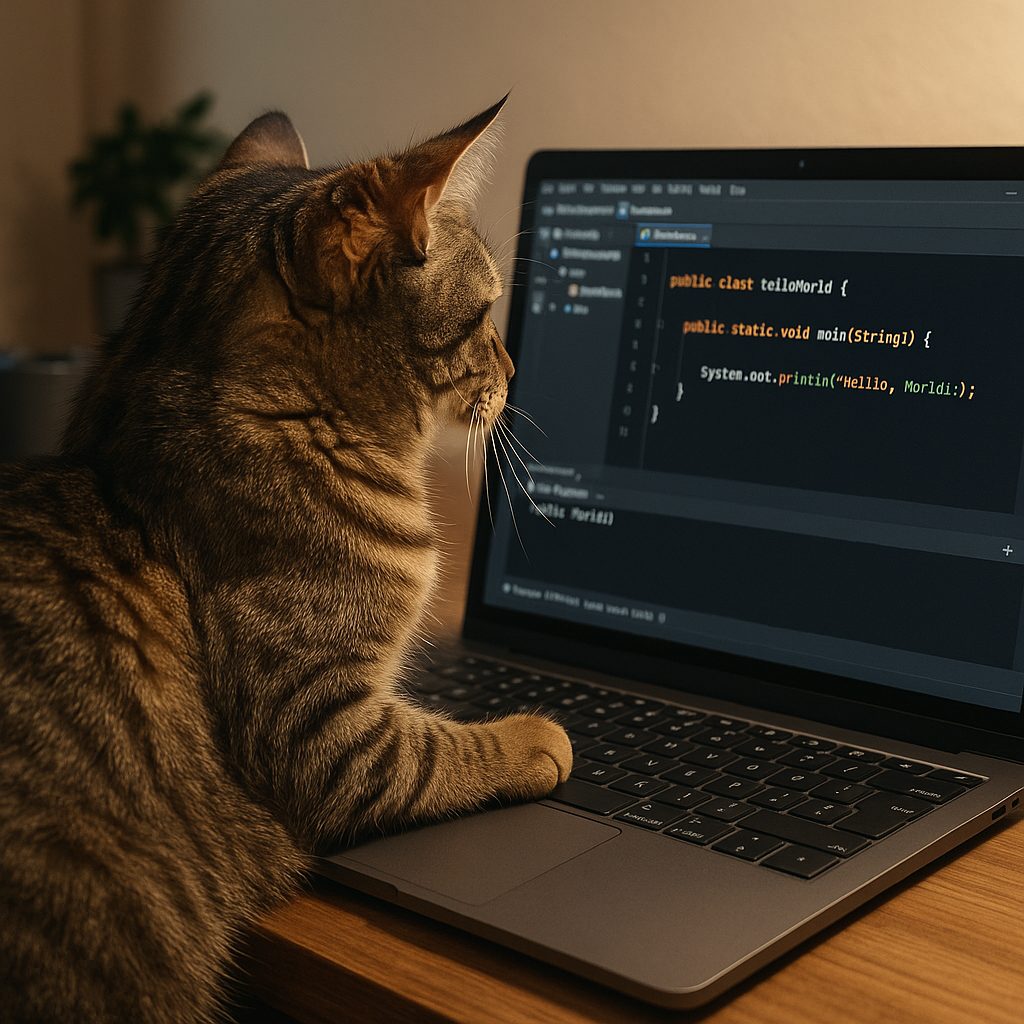

In [19]:
from langchain_core.messages import HumanMessage
llm4 = ChatOpenAI(model="gpt-5.2")
llm_with_tools = llm4.bind_tools([{"type":"image_generation", "quality":"high"}])

resp4 = llm_with_tools.invoke(input=[HumanMessage("Je veux une photo d'un chat qui code du java")])

from IPython.display import Image
import base64

Image(base64.b64decode(resp4.content_blocks[0]['base64']))

In [14]:
from langchain_openai import ChatOpenAI
from langchain.messages import SystemMessage as sys, HumanMessage as hum 


model=ChatOpenAI(model="gpt-5.2", temperature=0, model_kwargs={"response_format":{"type":"json_object"}})
system_message = """
Effectuez une analyse de sentiments basée sur les aspects des avis concernant
les ordinateurs portables présentés en entrée.

Chaque avis peut comporter un ou plusieurs des aspects suivants : screen, key-
bloard et pad.

Pour chaque avis présenté en entrée :
- Identifiez la présence d'au moins un des trois aspects (screen, keybloard,
pad).
- Attribuez une polarité de sentiment (positive, negative ou neutral) à chaque

aspect. Organisez votre réponse dans un objet JSON avec les en-têtes sui-
vants :

- category:[liste des aspects]
- polarity:[liste des polarités correspondantes pour chaque aspect]

Si l'un des aspects n'est pas présent dans l'avis de l'utilisateur, tu sup-
poses que la polarité est neutre

"""
resp= model.invoke([
    sys(system_message),
    hum("L'écran est très bon, mais je n'ai pas aimé la souris. le clavier Ma fih Maytchaf")
])


response_text_json=resp.content;

print(response_text_json)
import json
result=json.loads(response_text_json)


{
  "category": ["screen", "keybloard", "pad"],
  "polarity": ["positive", "neutral", "negative"]
}


In [10]:
from langchain_openai import ChatOpenAI
from langchain.messages import SystemMessage as sys, HumanMessage as hum 
from IPython.display import Image, Markdown
import base64
path ="rag.png"
Image(path)
llm5 = ChatOpenAI(model="gpt-5.2")

def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")

img = encode_image(path)

resp5 = llm5.invoke(input=[
hum(content=[
{"type":"text","text":"Qu'est ce que tu vois dans cette image"},
{"type":"image_url", "image_url": {"url":
f"data:image/png;base64,{img}"}}
])])

print(display(Markdown(resp5.content)))

L’image est un schéma (en français) qui illustre le fonctionnement d’un système **RAG** (*Retrieval-Augmented Generation*, génération augmentée par recherche) en **4 étapes** :

1. **Requête utilisateur** : un utilisateur pose une **question**.
2. **Recherche & récupération (Retrieval)** :
   - une **base de connaissances externe** est **indexée** et transformée en **embeddings**,
   - ces embeddings sont stockés dans une **base de vecteurs (vector database)**,
   - un **moteur de recherche** effectue une **recherche de vecteurs** pour retrouver les **segments pertinents & le contexte**.
3. **Génération (Generation)** :
   - la question + le **contexte augmenté** sont envoyés à un **modèle de langage (LLM)**.
4. **Réponse enrichie** : le système renvoie une réponse plus précise grâce aux informations récupérées.

None
